In [12]:
%pip install plotly nbformat

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('world_happiness_2023.csv')
df.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
              'Life_Expectancy','Freedom','Generosity','Corruption']
print(df.shape)

(63, 9)


                         Region  Happiness_Score
5                    South Asia         3.618250
7            Sub-Saharan Africa         4.064714
3  Middle East and North Africa         4.943333
6                Southeast Asia         5.695250
2   Latin America and Caribbean         5.699000
1                     East Asia         5.966000
0    Central and Eastern Europe         6.338143
4         North America and ANZ         7.018250
8                Western Europe         7.085533


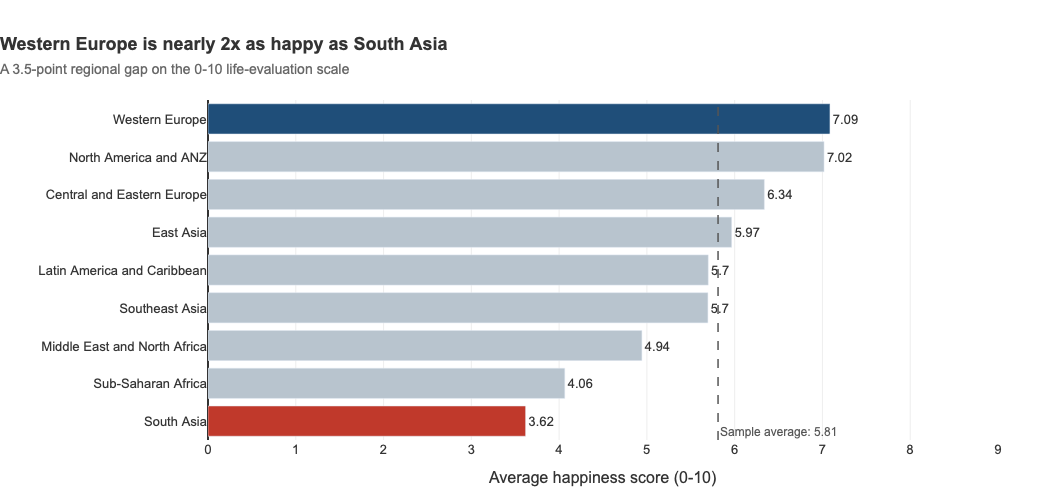

In [13]:
# Task 1: Regional comparison bar chart
region_avg = (df.groupby('Region')['Happiness_Score']
              .mean()
              .reset_index()
              .sort_values('Happiness_Score'))  # ascending: Plotly draws the last bar at the top

print(region_avg)

global_avg = df['Happiness_Score'].mean()
top_region = region_avg.iloc[-1]
low_region = region_avg.iloc[0]
gap = top_region['Happiness_Score'] - low_region['Happiness_Score']

# Highlight best and worst regions, mute the rest
colors = ['#C0392B' if r == low_region['Region']
          else '#1F4E79' if r == top_region['Region']
          else '#B8C4CE'
          for r in region_avg['Region']]

fig = go.Figure(go.Bar(
    x=region_avg['Happiness_Score'],
    y=region_avg['Region'],
    orientation='h',
    marker_color=colors,
    text=region_avg['Happiness_Score'].round(2),
    textposition='outside',
    cliponaxis=False,
    hovertemplate='%{y}: %{x:.2f}<extra></extra>',
))

fig.add_vline(x=global_avg, line_dash='dash', line_color='#555', line_width=1.5,
              annotation_text=f'Sample average: {global_avg:.2f}',
              annotation_position='bottom right',
              annotation_font=dict(size=12, color='#555'))

fig.update_layout(
    title=dict(
        text=(f"<b>{top_region['Region']} is nearly 2x as happy as {low_region['Region']}</b><br>"
              f"<span style='font-size:14px;color:#666'>A {gap:.1f}-point regional gap on the 0-10 "
              f"life-evaluation scale</span>"),
        x=0.0, xanchor='left'),
    xaxis=dict(title='Average happiness score (0-10)', range=[0, 9], showgrid=True,
               gridcolor='#EEE', zeroline=True, zerolinecolor='#333'),  # zero baseline
    yaxis=dict(title='', automargin=True),
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial, sans-serif', size=13, color='#333'),
    margin=dict(l=20, r=40, t=100, b=60),
    height=500, width=900, showlegend=False,
)
fig.show()

Global average: 5.81


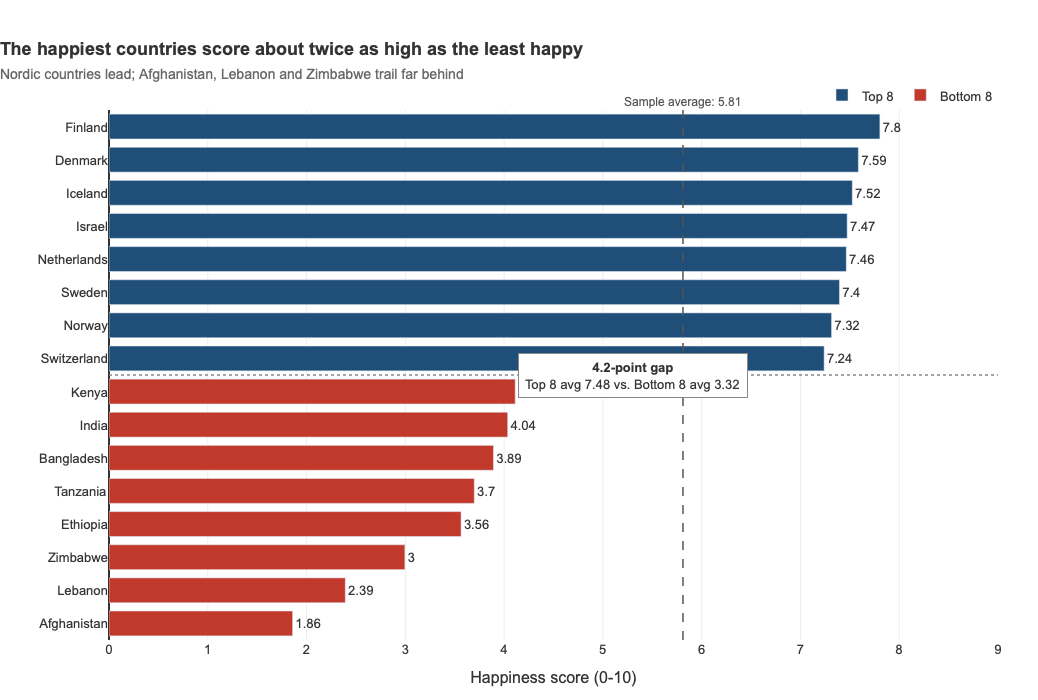

In [14]:
# Task 2: Top 8 vs. Bottom 8 contrast
top8 = df.nlargest(8, 'Happiness_Score').copy()
top8['Group'] = 'Top 8'
bottom8 = df.nsmallest(8, 'Happiness_Score').copy()
bottom8['Group'] = 'Bottom 8'

combined = pd.concat([bottom8, top8]).sort_values('Happiness_Score')
global_avg = df['Happiness_Score'].mean()
print(f"Global average: {global_avg:.2f}")

top_mean = top8['Happiness_Score'].mean()
bottom_mean = bottom8['Happiness_Score'].mean()
gap = top_mean - bottom_mean

color_map = {'Top 8': '#1F4E79', 'Bottom 8': '#C0392B'}

fig = go.Figure()
for group in ['Top 8', 'Bottom 8']:
    sub = combined[combined['Group'] == group]
    fig.add_trace(go.Bar(
        x=sub['Happiness_Score'], y=sub['Country'], orientation='h',
        name=group, marker_color=color_map[group],
        text=sub['Happiness_Score'].round(2), textposition='outside',
        cliponaxis=False,
        hovertemplate='%{y}: %{x:.2f}<extra></extra>',
    ))

# Keep sorted order (lowest at bottom, highest at top)
fig.update_yaxes(categoryorder='array', categoryarray=combined['Country'].tolist())

# Separator between the two groups
fig.add_hline(y=7.5, line_dash='dot', line_color='#888', line_width=1.5)

# Stretch: global average line
fig.add_vline(x=global_avg, line_dash='dash', line_color='#555', line_width=1.5,
              annotation_text=f'Sample average: {global_avg:.2f}',
              annotation_position='top', annotation_font=dict(size=12, color='#555'))

# Gap annotation
fig.add_annotation(
    x=5.3, y=7.5, xref='x', yref='y', showarrow=False,
    text=f"<b>{gap:.1f}-point gap</b><br>Top 8 avg {top_mean:.2f} vs. Bottom 8 avg {bottom_mean:.2f}",
    align='center', bgcolor='white', bordercolor='#888', borderwidth=1, borderpad=6,
    font=dict(size=13, color='#333'))

fig.update_layout(
    title=dict(
        text=("<b>The happiest countries score about twice as high as the least happy</b><br>"
              "<span style='font-size:14px;color:#666'>Nordic countries lead; Afghanistan, "
              "Lebanon and Zimbabwe trail far behind</span>"),
        x=0.0, xanchor='left'),
    xaxis=dict(title='Happiness score (0-10)', range=[0, 9], showgrid=True,
               gridcolor='#EEE', zeroline=True, zerolinecolor='#333'),
    yaxis=dict(title='', automargin=True),
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial, sans-serif', size=13, color='#333'),
    legend=dict(orientation='h', yanchor='bottom', y=1.0, xanchor='right', x=1.0),
    margin=dict(l=20, r=40, t=110, b=60),
    height=700, width=900, bargap=0.25,
)
fig.show()

                              GDP  Freedom
Region                                    
Western Europe               0.87     0.89
Latin America and Caribbean  0.54     0.64
East Asia                    0.75     0.64
Sub-Saharan Africa           0.16     0.38
South Asia                   0.18     0.28


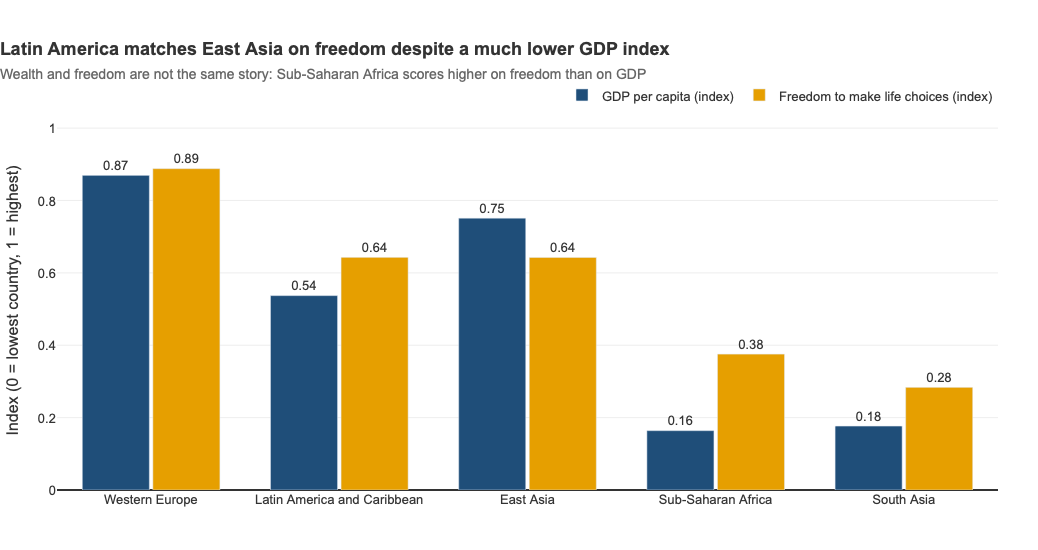

In [15]:
# Stretch goal — grouped bar chart
regions = ['Western Europe', 'Latin America and Caribbean', 'East Asia',
           'Sub-Saharan Africa', 'South Asia']

# GDP (log, ~6-12) and Freedom (0-1) are on different scales -> rescale both to a 0-1 index
scaled = df.copy()
for col in ['GDP', 'Freedom']:
    scaled[col] = (scaled[col] - scaled[col].min()) / (scaled[col].max() - scaled[col].min())

grp = (scaled[scaled['Region'].isin(regions)]
       .groupby('Region')[['GDP', 'Freedom']].mean()
       .reindex(regions))
print(grp.round(2))

fig = go.Figure()
fig.add_trace(go.Bar(x=grp.index, y=grp['GDP'], name='GDP per capita (index)',
                     marker_color='#1F4E79', text=grp['GDP'].round(2), textposition='outside'))
fig.add_trace(go.Bar(x=grp.index, y=grp['Freedom'], name='Freedom to make life choices (index)',
                     marker_color='#E69F00', text=grp['Freedom'].round(2), textposition='outside'))

fig.update_layout(
    barmode='group', bargap=0.25, bargroupgap=0.05,
    title=dict(
        text=("<b>Latin America matches East Asia on freedom despite a much lower GDP index</b><br>"
              "<span style='font-size:14px;color:#666'>Wealth and freedom are not the same story: "
              "Sub-Saharan Africa scores higher on freedom than on GDP</span>"),
        x=0.0, xanchor='left'),
    yaxis=dict(title='Index (0 = lowest country, 1 = highest)', range=[0, 1.05],
               showgrid=True, gridcolor='#EEE', zeroline=True, zerolinecolor='#333'),
    xaxis=dict(title=''),
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial, sans-serif', size=13, color='#333'),
    legend=dict(orientation='h', yanchor='bottom', y=1.0, xanchor='right', x=1.0),
    margin=dict(l=20, r=40, t=110, b=60),
    height=550, width=950,
)
fig.show()